## Settings and imports

In [1]:
import numpy as np
import pandas as pd
import os
import torch
import matplotlib.pyplot as plt
import string
from torch import nn
from torch.utils.data import Dataset, DataLoader
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize

In [2]:
object_name = 'Documents_XVIII_century' # Books / Documents_XVIII_century

In [3]:
if object_name == 'Books':
    real_or_simulated = 'real' #simulated / real / all
    #comment: in case of classification problem, we skip augmentation, read below why

keep_sample_together = False #Should all 15 slices from the same sample go together to the same set (train/test)?
if keep_sample_together:
    sample_together = 'sample_together'
else:
    sample_together = 'sample_split'
    
preprocessing_method = 'logarithm' # none / normalization / logarithm

columns_to_keep_inks = {
                        'Books': [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inks',
                                                 'S_inks',
                                                 'Cr_inks',
                                                 'Mn_inks',
                                                 'Co_inks',
                                                 'Cu_inks',
                                                 'Zn_inks',
                                                 'Pb_inks'
                                                            ],
    
                        'Konstytucja' : [
                                                 'Al',
                                                 'S',
                                                 'Cr',
                                                 'Mn',
                                                 'Co',
                                                 'Cu',
                                                 'Zn',
                                                 'Pb'
                                                            ]
    
                        }

columns_to_keep_inds = { 
                        'Books' : [
                            
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'],
    
                        'Documents_XVIII_century' : [
                                                 'Al_inds',
                                                 'S_inds',
                                                 'Cr_inds',
                                                 'Mn_inds',
                                                 'Co_inds',
                                                 'Cu_inds',
                                                 'Zn_inds',
                                                 'Pb_inds'
                                                        ],
                        'Konstytucja' : []
    
                        }

In [4]:
data_path = {'Books' : '../data/DANE.xlsx',
             'Documents_XVIII_century' : '../data/Lipiec_2024.xlsx',
             'Konstytucja' : '../data/Lipiec_2024.xlsx'}

results_path = {'Books' : '../results/Books/',
                'Documents_XVIII_century' : '../results/Documents_XVIII_century/',
                'Konstytucja' : '../results/Konstytucja/'}

figures_path = {'Books' : '../results/visualisations/Books/',
                'Documents_XVIII_century' : '../results/visualisations/Documents_XVIII_century/',
                'Konstytucja': '../results/visualisations/Konstytucja/'}

models_path = {'Books' : '../models/Books/',
                'Documents_XVIII_century' : '../models/Documents_XVIII_century/',
                'Konstytucja' : '../models/Konstytucja/'}

## Loading the data

In [5]:
df = pd.ExcelFile(data_path[object_name])

if object_name == 'Books':
    if real_or_simulated == 'simulated':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[:1425] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[:1425]  #inDs
    elif real_or_simulated == 'real':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list)[1425:] #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list)[1425:]  #inDs
    elif real_or_simulated == 'all':
        inks_df = df.parse('a.', header=0, index_col=0, usecols=list) #inKs
        inds_df = df.parse('i.', header=0, index_col=0, usecols=list) #inDs

elif object_name == 'Documents_XVIII_century':
    inks_df = df.parse('Arkusz1', header=0, usecols=range(2,29), skiprows=range(3931, 4742))
    inds_df = df.parse('Arkusz1', header=0, usecols=range(32,59), skiprows=range(3931, 4742))
    inds_df.columns = inks_df.columns

## Preprocessing

### Joining corresponding samples from inds and inks into one table

In [6]:
inks_df = inks_df.reset_index(drop=False)
inds_df = inds_df.reset_index(drop=False)
inDKs_df = inds_df.join(inks_df, how='inner', rsuffix='_inks', lsuffix='_inds')

### Keeping track of the records from the same sample

In [7]:
inDKs_df['Sample_id'] = np.repeat(range(int(inDKs_df.shape[0]/15)), 15, axis=0)

### Removing some data

1. Let's keep only columns that we need.

To reduce the set of used elements run cell below. Then, instead of predicting 29 numbers, we will predict only 8. We will also use only 8 numbers as input.

In [8]:
inDKs_df = inDKs_df[columns_to_keep_inks[object_name] + columns_to_keep_inds[object_name] + ['Sample_id']]

2. Let's remove rows with missing values.

In [9]:
(inds_df.shape[0] - inds_df.dropna().shape[0])/inds_df.shape[0]

0.007888040712468193

In [10]:
inds_df.dropna(inplace=True)

### Data augmentation

In case of classification task we skip augmentation, because it's not clear how to perform it and what class to use as label.

### Removing inks values, keeping only inds and classes

In [11]:
inDKs_df = inDKs_df[[col for col in inDKs_df.columns if not col.endswith('_inks')]]

############################

## Creating labels

In [12]:
X = inDKs_df[[col for col in inDKs_df.columns if not col == 'Sample_id']]
X.reset_index(drop=True, inplace=True)
y = pd.get_dummies(inDKs_df['Sample_id'])
y.reset_index(drop=True, inplace=True)
inDKs_df = pd.concat([X,y], axis=1)

In [13]:
inDKs_df.columns = [str(col) for col in inDKs_df.columns]

## Train test split, dataloaders

In [14]:
if keep_sample_together:
    
    indices = list(inDKs_df['Sample_id'].unique())
    
    ind_train, ind_test = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train, ind_val = train_test_split(ind_train, test_size=0.25, random_state=1)
    
    X_y_train = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_train)]
    X_y_val = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_val)]
    X_y_test = inDKs_df[inDKs_df['Sample_id'].apply(lambda x: x in ind_test)]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

else:
    indices = list(range(int(inDKs_df.shape[0])))
    ind_train_all, ind_test_all = train_test_split(indices, test_size=0.2, random_state=1)
    ind_train_all, ind_val_all = train_test_split(ind_train_all, test_size=0.25, random_state=1)
    
    partition = {'train': ind_train_all,
             'val': ind_val_all,
            'test': ind_test_all}
    
    X_y_train = inDKs_df.iloc[partition['train'],:]
    X_y_val = inDKs_df.iloc[partition['val'],:]
    X_y_test = inDKs_df.iloc[partition['test'],:]
    
    X_y_train.reset_index(drop=True, inplace=True)
    X_y_val.reset_index(drop=True, inplace=True)
    X_y_test.reset_index(drop=True, inplace=True)

In [15]:
X_train = np.array(X_y_train[[col for col in X_y_train.columns if col.endswith('_inds')]].values)
y_train = np.array(X_y_train[[col for col in X_y_train.columns if not col.endswith('_inds')]].values)
X_val = np.array(X_y_val[[col for col in X_y_val.columns if col.endswith('_inds')]].values)
y_val = np.array(X_y_val[[col for col in X_y_val.columns if not col.endswith('_inds')]].values)
X_test = np.array(X_y_test[[col for col in X_y_test.columns if col.endswith('_inds')]].values)
y_test = np.array(X_y_test[[col for col in X_y_test.columns if not col.endswith('_inds')]].values)

## Normalizing / taking logarithm

In [16]:
def adjusted_log_transform(nonnegative_array):
    res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)
    res = np.where(res != 0, res, 2*res.min(axis=0))
    return res

In [17]:
if preprocessing_method == 'normalization':

    X_train = (X_train - np.min(X_train, axis=0))/np.std(X_train, axis=0)
    X_val = (X_val - np.min(X_val, axis=0))/np.std(X_val, axis=0)
    X_test = (X_test - np.min(X_test, axis=0))/np.std(X_test, axis=0)
    
elif preprocessing_method == 'logarithm':
    
    X_train = adjusted_log_transform(X_train)
    X_val = adjusted_log_transform(X_val)
    X_test = adjusted_log_transform(X_test)
    
elif preprocessing_method == 'none':
    
    pass

/tmp/ipykernel_4820/1324458353.py:2: RuntimeWarning: divide by zero encountered in log
  res = np.where(nonnegative_array>0, np.log(nonnegative_array), 0.)


(array([ 18.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.,   1.,   0.,   0.,   1.,   0.,   0.,   0.,   2.,   2.,   0.,
          3.,   2.,   7.,   4.,  12.,   9.,  11.,  31.,  41.,  39.,  51.,
         58.,  78.,  77.,  99., 143., 118., 160., 140., 102., 101., 107.,
        148., 123., 107.,  92.,  72.,  70.,  38.,  21.,  37.,  35.,  37.,
         48.,  15.,  32.,  26.,  15.,  10.,   2.,   0.,   1.,   2.,   5.,
          4.]),
 array([-20.09713206, -19.87242592, -19.64771977, -19.42301363,
        -19.19830749, -18.97360134, -18.7488952 , -18.52418906,
        -18.29948291, -18.07477677, -17.85007063, -17.62536448,
        -17.40065834, -17.17595219, -16.95124605, -16.72653991,
        -16.50183376, -16.27712762, -16.05242148, -15.82771533

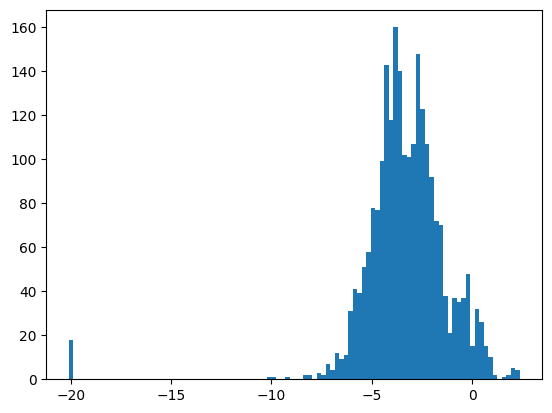

In [18]:
coor = 6
plt.hist(X_train[:,coor], bins=100)
#plt.hist(X_test[:,coor], bins=100)

## Converting to tensors

In [19]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using cuda device


In [20]:
X_train = torch.Tensor(X_train).to(device)
y_train = torch.Tensor(y_train).to(device)
    
X_val = torch.Tensor(X_val).to(device)
y_val = torch.Tensor(y_val).to(device)
X_test = torch.Tensor(X_test).to(device)
y_test = torch.Tensor(y_test).to(device)

## Dataset

In [21]:
class InksDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
        
    def __getitem__(self, index):
        return self.X[index, :], self.y[index, :]
    
    def __len__(self):
        assert self.X.shape[0] == self.y.shape[0]
        return self.X.shape[0]

In [22]:
train_dataset = InksDataset(X=X_train, y=y_train)
val_dataset = InksDataset(X=X_val, y=y_val)
test_dataset = InksDataset(X=X_test, y=y_test)

In [23]:
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=10)
val_loader = DataLoader(val_dataset, shuffle=True)
test_loader = DataLoader(test_dataset, shuffle=False)

## Building neural network

In [24]:
input_size = X_train.shape[1]
output_size = y_train.shape[1]

For now, we keep only use very simple neural network.

In [25]:
class InksNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.seq = nn.Sequential(
        nn.Linear(input_size, input_size),
        nn.ReLU(),
        nn.Linear(input_size, 50),
        nn.ReLU(),
        nn.Linear(50, 100),
        nn.ReLU(),
        nn.Linear(100, output_size))
    def forward(self, x):
        return self.seq(x)

# dropout_prob = 0.1

# class InksNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.seq = nn.Sequential(
#         nn.Linear(input_size, input_size),
#         nn.Dropout(dropout_prob),
#         nn.ReLU(),
#         nn.Linear(input_size, 50),
#         nn.Dropout(dropout_prob),
#         nn.ReLU(),
#         nn.Linear(50, 100),
#         nn.Dropout(dropout_prob),
#         nn.ReLU(),
#         nn.Linear(100, output_size))
#     def forward(self, x):
#         return self.seq(x)

## Training

In [26]:
model = InksNet().to(device)
print(model)

InksNet(
  (seq): Sequential(
    (0): Linear(in_features=8, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=100, bias=True)
    (5): ReLU()
    (6): Linear(in_features=100, out_features=262, bias=True)
  )
)


In [27]:
def train_one_epoch(loader, loss_fn, optimizer):
    running_loss = 0.

    for i, batch in enumerate(loader):

        inputs, labels = batch ###

        optimizer.zero_grad()

        outputs = model(inputs)

        loss = loss_fn(outputs, labels)
        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader) # loss per batch
    return avg_loss

In [28]:
EPOCHS = 1000
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

epoch_number = 0

train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    print('EPOCH {}:'.format(epoch_number + 1))

    # Make sure gradient tracking is on, and do a pass over the data
    model.train(True)
    avg_loss = train_one_epoch(train_loader, loss_fn=loss_fn, optimizer=optimizer)


    running_vloss = 0.0
    # Set the model to evaluation mode, disabling dropout and using population
    # statistics for batch normalization.
    model.eval()

    # Disable gradient computation and reduce memory consumption.
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            inputs, labels = vdata
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_vloss += loss.item()
    
    avg_vloss = float(running_vloss / len(val_loader))
    print('LOSS train {} test {}'.format(avg_loss, avg_vloss))
    
    train_losses.append(avg_loss)
    val_losses.append(avg_vloss)

    epoch_number += 1

EPOCH 1:
LOSS train 5.567417215492766 test 5.556638155274719
EPOCH 2:
LOSS train 5.499291684667943 test 5.484518377532183
EPOCH 3:
LOSS train 5.376383072238857 test 5.359364997036281
EPOCH 4:
LOSS train 5.192566707982856 test 5.18565592784008
EPOCH 5:
LOSS train 4.949110558477499 test 4.947516593314309
EPOCH 6:
LOSS train 4.642974141290632 test 4.666448966540757
EPOCH 7:
LOSS train 4.3040124854799044 test 4.361578117800123
EPOCH 8:
LOSS train 3.968267169039128 test 4.065912783752568
EPOCH 9:
LOSS train 3.6694390713158302 test 3.8104882724109195
EPOCH 10:
LOSS train 3.4154948117369313 test 3.5925453326856815
EPOCH 11:
LOSS train 3.202800918433626 test 3.3981055051619165
EPOCH 12:
LOSS train 3.0202794943825673 test 3.24218022671668
EPOCH 13:
LOSS train 2.8684395713321234 test 3.1104066400355057
EPOCH 14:
LOSS train 2.73364281300771 test 3.004622850292208
EPOCH 15:
LOSS train 2.61851948802754 test 2.8885629246670175
EPOCH 16:
LOSS train 2.5183361915208526 test 2.8004257503432477
EPOCH 17:

LOSS train 0.6950999668846696 test 1.366190530227851
EPOCH 131:
LOSS train 0.6893716835874623 test 1.369358082648313
EPOCH 132:
LOSS train 0.6908260434234547 test 1.376116175104301
EPOCH 133:
LOSS train 0.6825593189352145 test 1.3816968684643076
EPOCH 134:
LOSS train 0.6849145565371392 test 1.3827341598666996
EPOCH 135:
LOSS train 0.6733041873549 test 1.381449782207628
EPOCH 136:
LOSS train 0.6676311264982668 test 1.3965278385008069
EPOCH 137:
LOSS train 0.6700511286193032 test 1.3727096287204374
EPOCH 138:
LOSS train 0.6636554548927283 test 1.392132706175767
EPOCH 139:
LOSS train 0.6565553043984761 test 1.3668436327649662
EPOCH 140:
LOSS train 0.6537854713466713 test 1.389598154807146
EPOCH 141:
LOSS train 0.6508945262975107 test 1.3988322088545109
EPOCH 142:
LOSS train 0.6516517845882197 test 1.4093524214224713
EPOCH 143:
LOSS train 0.6455362729286238 test 1.3601607556950337
EPOCH 144:
LOSS train 0.6473339716193535 test 1.34703755072335
EPOCH 145:
LOSS train 0.631902891132286 test 1.

LOSS train 0.396550306150595 test 1.186279806849419
EPOCH 258:
LOSS train 0.39340491418458395 test 1.2238974118538282
EPOCH 259:
LOSS train 0.3948703287721817 test 1.2400364563884458
EPOCH 260:
LOSS train 0.3915099827257001 test 1.2167319615132408
EPOCH 261:
LOSS train 0.3854972555980844 test 1.2340686796004832
EPOCH 262:
LOSS train 0.3940973500642231 test 1.2116117202006358
EPOCH 263:
LOSS train 0.38342654935510484 test 1.2461548122976698
EPOCH 264:
LOSS train 0.3890314990717728 test 1.2457096759938178
EPOCH 265:
LOSS train 0.37630397207656147 test 1.2362374865603258
EPOCH 266:
LOSS train 0.37716377764877124 test 1.2377805949901448
EPOCH 267:
LOSS train 0.38647876201607917 test 1.2505829337009455
EPOCH 268:
LOSS train 0.38180439816629985 test 1.287152804811149
EPOCH 269:
LOSS train 0.375062286695939 test 1.2343466140822748
EPOCH 270:
LOSS train 0.37764322176433596 test 1.2092912617417129
EPOCH 271:
LOSS train 0.3713083452845024 test 1.2317468006620973
EPOCH 272:
LOSS train 0.372349009

LOSS train 0.24988891092381613 test 1.2525588384635025
EPOCH 384:
LOSS train 0.23616735319906879 test 1.2170043079671113
EPOCH 385:
LOSS train 0.23646734567098635 test 1.2286948119603842
EPOCH 386:
LOSS train 0.2456013060616866 test 1.2872054220317362
EPOCH 387:
LOSS train 0.24292090471628738 test 1.2355602655175466
EPOCH 388:
LOSS train 0.24183006541629842 test 1.252667027693524
EPOCH 389:
LOSS train 0.23519738655837286 test 1.2430870967574925
EPOCH 390:
LOSS train 0.2376784008169957 test 1.1718544889335014
EPOCH 391:
LOSS train 0.23790531702166012 test 1.2458672074271542
EPOCH 392:
LOSS train 0.23763910056312837 test 1.2286689710002718
EPOCH 393:
LOSS train 0.23285683327733334 test 1.242428667415244
EPOCH 394:
LOSS train 0.23563199586598044 test 1.237053761323693
EPOCH 395:
LOSS train 0.23258904945026387 test 1.2120688390244763
EPOCH 396:
LOSS train 0.2332002649328403 test 1.2714325041912475
EPOCH 397:
LOSS train 0.22644071184272357 test 1.2601783428771445
EPOCH 398:
LOSS train 0.230

LOSS train 0.1516680002303289 test 1.2407185310906177
EPOCH 509:
LOSS train 0.15166892416250372 test 1.2808409442583075
EPOCH 510:
LOSS train 0.15366709645900686 test 1.2399825964400224
EPOCH 511:
LOSS train 0.1507462389546178 test 1.2888838911093217
EPOCH 512:
LOSS train 0.15075894282791386 test 1.2561666266062927
EPOCH 513:
LOSS train 0.14921268897320508 test 1.2685000441899383
EPOCH 514:
LOSS train 0.14379210074055324 test 1.2364071147775615
EPOCH 515:
LOSS train 0.14799015467662868 test 1.2773897479946497
EPOCH 516:
LOSS train 0.14975416996186772 test 1.2945975972461012
EPOCH 517:
LOSS train 0.14718804722928078 test 1.2723269337993557
EPOCH 518:
LOSS train 0.14125269307593136 test 1.2655999454595577
EPOCH 519:
LOSS train 0.14866725647312953 test 1.2152450379781432
EPOCH 520:
LOSS train 0.1491182361812315 test 1.2317194371269276
EPOCH 521:
LOSS train 0.14278127457571643 test 1.2760780824662497
EPOCH 522:
LOSS train 0.14708045637333703 test 1.2840647553127318
EPOCH 523:
LOSS train 0.

LOSS train 0.09745698747163692 test 1.3257121599401451
EPOCH 634:
LOSS train 0.09982815486913196 test 1.3898511992998375
EPOCH 635:
LOSS train 0.09869443691755897 test 1.336976187842771
EPOCH 636:
LOSS train 0.09478651140165373 test 1.351283100110496
EPOCH 637:
LOSS train 0.09340435299686684 test 1.360069476142836
EPOCH 638:
LOSS train 0.09789580060267758 test 1.3276226041191532
EPOCH 639:
LOSS train 0.09585678094003539 test 1.325628008267491
EPOCH 640:
LOSS train 0.09358006205150297 test 1.3585383911356241
EPOCH 641:
LOSS train 0.09428845935055229 test 1.3305114648479195
EPOCH 642:
LOSS train 0.0951922083345303 test 1.3595151934175522
EPOCH 643:
LOSS train 0.09183941122689047 test 1.3292723597543032
EPOCH 644:
LOSS train 0.09378733561903049 test 1.3386177097800234
EPOCH 645:
LOSS train 0.09356996809281369 test 1.3508594222114303
EPOCH 646:
LOSS train 0.09115676636910224 test 1.3236785376635527
EPOCH 647:
LOSS train 0.09580822729370439 test 1.3579285617149481
EPOCH 648:
LOSS train 0.09

LOSS train 0.06200580901201909 test 1.458043179528858
EPOCH 759:
LOSS train 0.06955216598464052 test 1.471286890148611
EPOCH 760:
LOSS train 0.06709450132627152 test 1.4579456668280695
EPOCH 761:
LOSS train 0.06428855096021573 test 1.4873960629873542
EPOCH 762:
LOSS train 0.05937614068161411 test 1.4462533964478625
EPOCH 763:
LOSS train 0.06444253533278489 test 1.5029741470882165
EPOCH 764:
LOSS train 0.06398073154282352 test 1.4674325069617435
EPOCH 765:
LOSS train 0.06462005306192145 test 1.4327913807470167
EPOCH 766:
LOSS train 0.0619976856214018 test 1.473836725464783
EPOCH 767:
LOSS train 0.06765967679832287 test 1.4716160164359364
EPOCH 768:
LOSS train 0.0625365511011712 test 1.4641720597153594
EPOCH 769:
LOSS train 0.06460127347174606 test 1.4420140579642908
EPOCH 770:
LOSS train 0.06215987175941552 test 1.4786547063247575
EPOCH 771:
LOSS train 0.061800282340377405 test 1.492009972112974
EPOCH 772:
LOSS train 0.060950129958840436 test 1.4664407576521108
EPOCH 773:
LOSS train 0.0

LOSS train 0.0468773315265719 test 1.5936408003715614
EPOCH 884:
LOSS train 0.04479171038535966 test 1.5931839179644798
EPOCH 885:
LOSS train 0.04758298266118553 test 1.5833264831305596
EPOCH 886:
LOSS train 0.042742376049457145 test 1.5921758451063168
EPOCH 887:
LOSS train 0.04316060442160036 test 1.6242549962012778
EPOCH 888:
LOSS train 0.04382186668855699 test 1.6156223613710037
EPOCH 889:
LOSS train 0.04443774478935111 test 1.5968608117366188
EPOCH 890:
LOSS train 0.04379885258403177 test 1.5950155450341221
EPOCH 891:
LOSS train 0.044370958584002404 test 1.6252517569276328
EPOCH 892:
LOSS train 0.04251004267465205 test 1.556142212552177
EPOCH 893:
LOSS train 0.04187477970633878 test 1.623727116027384
EPOCH 894:
LOSS train 0.0412448016422632 test 1.5831376756650328
EPOCH 895:
LOSS train 0.04309710227956248 test 1.6467831859826747
EPOCH 896:
LOSS train 0.04334017098306511 test 1.611631983368883
EPOCH 897:
LOSS train 0.04370407196003756 test 1.6256259118120475
EPOCH 898:
LOSS train 0.

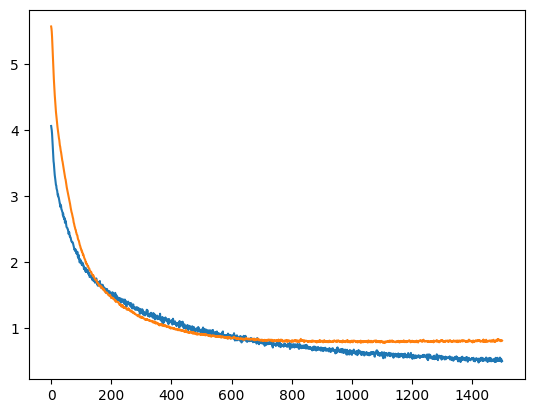

In [29]:
# 31.08.2024.
# documents
# logarithm
# batch_size=10
# dropout 0.1 x 3
plt.plot(train_losses)
plt.plot(val_losses)

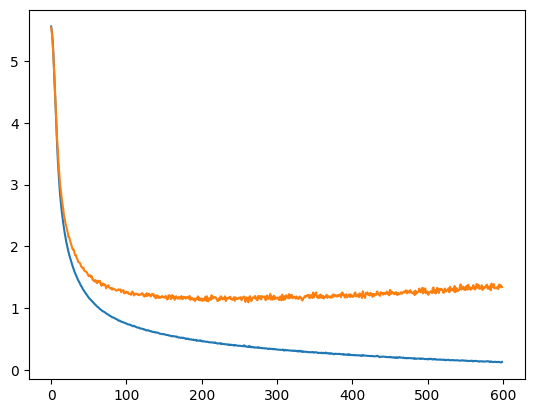

In [29]:
# 31.08.2024.
# documents
# logarithm
# batch_size=10
plt.plot(train_losses)
plt.plot(val_losses)

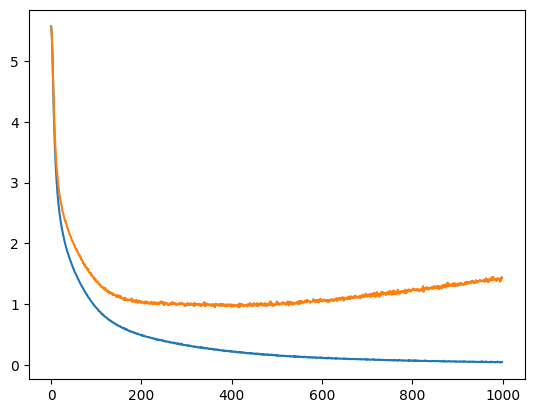

In [29]:
# 31.08.2024.
# documents
# logarithm
# batch_size=10
plt.plot(train_losses)
plt.plot(val_losses)

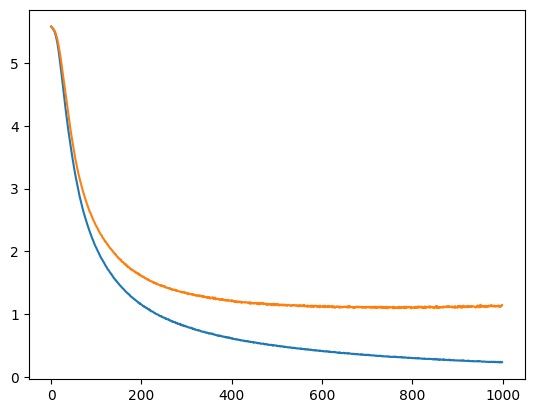

In [29]:
# 31.08.2024.
# documents
# logarithm
plt.plot(train_losses)
plt.plot(val_losses)

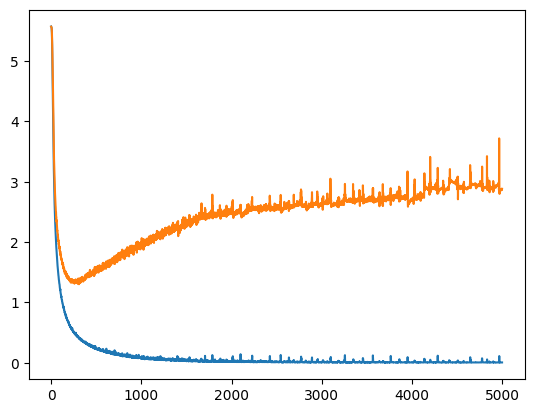

In [29]:
# 30.08.2024.
# documents
# logarithm
# larger network
plt.plot(train_losses)
plt.plot(val_losses)

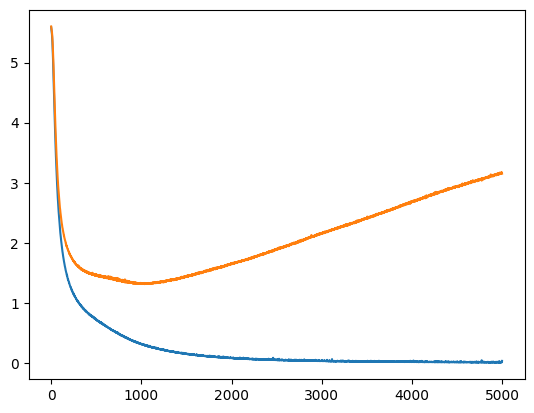

In [28]:
# 28.08.2024.
# documents
# logarithm
plt.plot(train_losses)
plt.plot(val_losses)

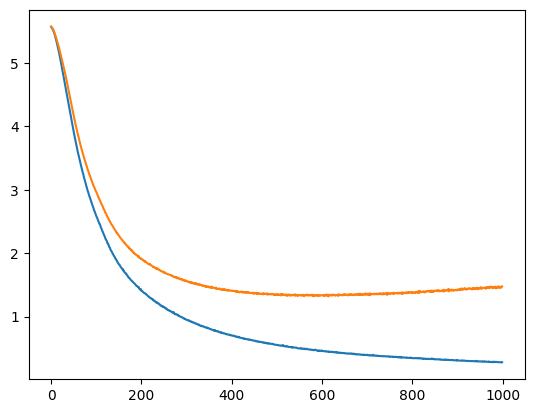

In [28]:
# 17.08.2024.
# documents
# logarithm
plt.plot(train_losses)
plt.plot(val_losses)

In [ ]:
# 17.08.2024.
# documents
# normalization
plt.plot(train_losses)
plt.plot(val_losses)

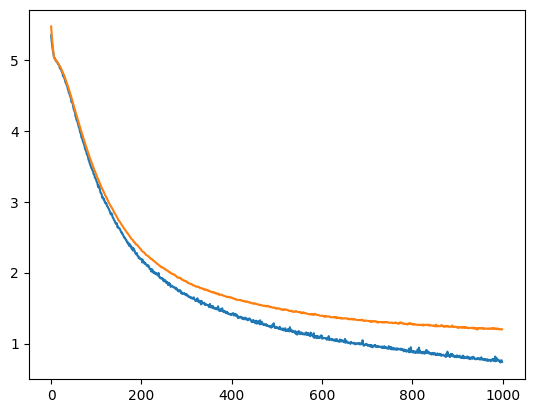

In [29]:
# 17.08.2024.
# books
# no transformation
plt.plot(train_losses)
plt.plot(val_losses)

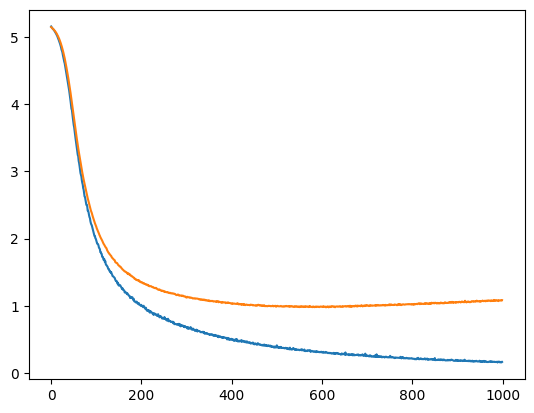

In [28]:
# 17.08.2024.
# books
# logarithm
plt.plot(train_losses)
plt.plot(val_losses)

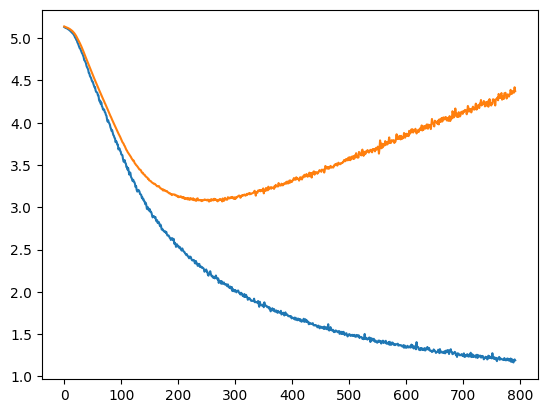

In [28]:
# 17.08.2024.
# books
# normalization
plt.plot(train_losses)
plt.plot(val_losses)

In [29]:
model.eval()
correct = 0
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    labels_class = labels.argmax()
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_10280/3545108458.py:6: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [30]:
acc

0.847328245639801

In [34]:
import time
ts = time.time()
import datetime
now = datetime.datetime.fromtimestamp(ts).strftime('%Y_%m_%d_%H_%M_%S')

torch.save(model.state_dict(), models_path[object_name]+'model_classification_'+now)

In [ ]:
# Documents
# batch_size=10, dropout, 1500 epochs
# 0.864 / 0.837

# Documents
# batch_size=10, dropout, 1000 epochs
# 0.841 / 0.831 / 0.809 / 0.841 / 0.851 / 0.838 / 0.807 / 0.828 / 0.831 / 0.833

# Documents
# batch_size=10, no dropout

# 0.803 / 0.851 / 0.846 / 0.859 / 0.831 / 0.818 / 0.817 / 0.858 / 0.828 / 0.841

# Documents:
# batch_size = 100

# logarithm: 0.75 / 0.78 / 0.79 / 0.81 / 0.82 / 0.83 / 0.83 / 0.84 / 0.84 / 0.87

In [ ]:
# Books:
# no transformation: 0.70
# normalization: 0.2
# logarithm: 0.85

# Documents:

# logarithm: 0.75 / 0.78 / 0.79 / 0.81 / 0.82 / 0.83 / 0.83 / 0.84 / 0.84 / 0.87


In [31]:
np.mean([0.841, 0.831, 0.809, 0.841, 0.851, 0.838, 0.807, 0.828, 0.831, 0.833])

0.8310000000000001

In [31]:
np.mean([0.803, 0.851, 0.846, 0.859, 0.831, 0.818, 0.817, 0.858, 0.828, 0.841])

0.8352

In [32]:
#np.mean([0.75, 0.78, 0.79, 0.81, 0.82, 0.83, 0.83, 0.84, 0.84, 0.87])

0.8159999999999998

## Visualisation with confusion matrix

In [34]:
model.eval()
correct = 0
labels_saved = []
outputs_saved = []
for i, tdata in enumerate(test_loader):
    inputs, labels = tdata
    outputs = model(inputs)
    outputs_class = nn.functional.softmax(outputs).argmax()
    outputs_saved.append(int(outputs_class))
    labels_class = labels.argmax()
    labels_saved.append(int(labels_class))
    correct += (outputs_class == labels_class)*1
acc = float(correct / len(test_loader))

/tmp/ipykernel_15686/1097759078.py:8: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  outputs_class = nn.functional.softmax(outputs).argmax()


In [35]:
import seaborn as sns

NameError: name 'real_or_simulated' is not defined

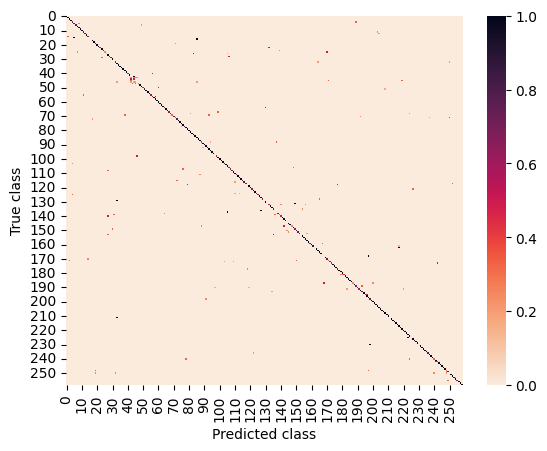

In [36]:
conf_mat = sklearn.metrics.confusion_matrix(labels_saved, outputs_saved, normalize='true')
sns.heatmap(conf_mat, cmap=sns.cm.rocket_r)
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.savefig('../results/visualisations/heatmap_'+real_or_simulated+'.png')